<a href="https://colab.research.google.com/github/Youssef-Chip/lab1/blob/main/lab4/check3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
"""
ENVIRONMENT SETUP & DATA LOADING
"""
import pandas as pd
import requests
from sklearn.model_selection import train_test_split

# Download the MovieLens 100k dataset
print("Downloading MovieLens 100K dataset...")
url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"
response = requests.get(url)

# Save to a local file
with open("u.data", "wb") as f:
  f.write(response.content)

# Read the data into a Pandas DataFrame
# The file is separated by tabs ('\t') and has no header row
columns = ["user_id", "item_id", "rating", "timestamp"]
df = pd.read_csv("u.data", sep='\t', names=columns)

# We don't need timestamp
df = df.drop("timestamp", axis=1)

# Create the 80/20 Train and Test Split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Display stats
print(f"Data loaded successfully!")
print(f"Total Unique Users: {df["user_id"].nunique()}")
print(f"Total Unique Movies: {df["item_id"].nunique()}")
print(f"Ratings in Training Set: {len(train_df)}")

# Calculate Sparsity
total_possible_ratings = df["user_id"].nunique() * df["item_id"].nunique()
actual_ratings = len(df)
sparsity = (1.0 - (actual_ratings / total_possible_ratings)) * 100

print(f"Matrix Sparsity: {sparsity:.2f}%")

print("\n--- Training Data Sample ---")
print(train_df.head(3))

Data loaded successfully!
Total Unique Users: 943
Total Unique Movies: 1682
Ratings in Training Set: 80000
Matrix Sparsity: 93.70%

--- Training Data Sample ---
       user_id  item_id  rating
75220      807     1411       1
48955      474      659       5
44966      463      268       4


In [3]:
"""
BASELINE MODEL
"""
import numpy as np
from sklearn.metrics import mean_squared_error

# Calculate the Global Mean
global_mean = train_df["rating"].mean()
print(f"Global Average Rating: {global_mean:.2f} stars")

# Calculate the Item Mean (Average rating for each movie)
# We group the training data by movie and calculate the mean of the ratings
item_means = train_df.groupby("item_id")["rating"].mean().rename("item_mean")

# Make predictions on the Test Set
# We merge the item means into our test dataframe
test_predictions = test_df.merge(item_means, on="item_id", how="left")

# If a movie wasn't in the training set, its "item_mean" will be NaN. We fill
# those blanks with the global mean
test_predictions["item_mean"] = test_predictions["item_mean"].fillna(global_mean)

# Evaluate the Baseline with RMSE
# RMSE compares the true "rating" against our predicted "item_mean"
baseline_rmse = np.sqrt(mean_squared_error(test_predictions["rating"], test_predictions["item_mean"]))

print(f"--- Baseline Evaluation ---")
print(f"Baseline (Item Mean) RMSE: {baseline_rmse:.4f}")

Global Average Rating: 3.53 stars
--- Baseline Evaluation ---
Baseline (Item Mean) RMSE: 1.0210


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

# Build the PyTorch Dataset
class MovieLensDataset(Dataset):
  def __init__(self, dataframe):
    self.users = torch.tensor([user_ids[u] for u in dataframe["user_id"].values])
    self.items = torch.tensor([item_ids[i] for i in dataframe["item_id"].values])
    self.ratings = torch.tensor(dataframe["rating"].values, dtype=torch.float32)

  def __len__(self):
    return len(self.ratings)

  def __getitem__(self, idx):
    return self.users[idx], self.items[idx], self.ratings[idx]

In [5]:
"""
MATRIX FACTORIZATION
"""
# Clean the IDs
# Neural networks need IDs to be perfect sequences starting at 0 (0, 1, 2, 3, ...)
# MovieLens IDs sometimes skip numbers, so we map them to clean integer indexes.
user_ids = {id: idx for idx, id in enumerate(df["user_id"].unique())}
item_ids = {id: idx for idx, id in enumerate(df["item_id"].unique())}

num_users = len(user_ids)
num_items = len(item_ids)

# Create DataLoaders to feed batches to our model
train_loader = DataLoader(MovieLensDataset(train_df), batch_size=1024, shuffle=True)
test_loader = DataLoader(MovieLensDataset(test_df), batch_size=1024, shuffle=False)

In [16]:
class MatrixFactorization(nn.Module):
  def __init__(self, num_users, num_items, embed_size=8):
    super().__init__()
    # The lookup tables (latent features for every user and item)
    self.user_embed = nn.Embedding(num_users, embed_size)
    self.item_embed = nn.Embedding(num_items, embed_size)

    # Biases: Some users rate everything low and some movies are universally
    # loved
    self.user_bias = nn.Embedding(num_users, 1)
    self.item_bias = nn.Embedding(num_items, 1)
    self.global_bias = nn.Parameter(torch.tensor([3.53])) # Start at the global mean

  def forward(self, user, item):
    # Grab the vectors
    u_vector = self.user_embed(user)
    i_vector = self.item_embed(item)

    # The Dot Product (Multiply them together and sum them up)
    dot_product = (u_vector * i_vector).sum(dim=1, keepdim=True)

    # Add the biases and return the predicted star rating
    prediction = dot_product + self.user_bias(user) + self.item_bias(item) + self.global_bias
    return torch.clamp(prediction.squeeze(), 1.0, 5.0)

In [17]:
# Initialize Model, Loss, and Optimizer
model = MatrixFactorization(num_users, num_items, embed_size=8)
criterion = nn.MSELoss() # Mean Squared Error
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-3)

In [18]:
# Training Loop
print("Training the Matrix Factorization Model...")
epochs = 10

for epoch in range(epochs):
  model.train()
  total_loss = 0
  for users, items, ratings in train_loader:
    optimizer.zero_grad()
    predictions = model(users, items)

    loss = criterion(predictions, ratings)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  print(f"Epoch {epoch+1}/{epochs} | Train Loss (MSE): {total_loss / len(train_loader):.4f}")


Training the Matrix Factorization Model...
Epoch 1/10 | Train Loss (MSE): 3.1917
Epoch 2/10 | Train Loss (MSE): 1.9968
Epoch 3/10 | Train Loss (MSE): 1.2272
Epoch 4/10 | Train Loss (MSE): 0.9692
Epoch 5/10 | Train Loss (MSE): 0.9175
Epoch 6/10 | Train Loss (MSE): 0.9103
Epoch 7/10 | Train Loss (MSE): 0.9027
Epoch 8/10 | Train Loss (MSE): 0.9066
Epoch 9/10 | Train Loss (MSE): 0.9082
Epoch 10/10 | Train Loss (MSE): 0.9076


In [19]:
# Evaluate on the Test Set
model.eval()
test_loss = 0
with torch.no_grad():
  for users, items, ratings in test_loader:
    predictions = model(users, items)
    loss = criterion(predictions, ratings)
    test_loss += loss.item()

In [20]:
# Calculate Final RMSE
mf_rmse = np.sqrt(test_loss / len(test_loader))
print(f"--- Final Evaluation ---")
print(f"Strong Model (Matrix Factorization) RMSE: {mf_rmse:.4f}")
print(f"Baseline (Item Mean) RMSE: {baseline_rmse:.4f}")

--- Final Evaluation ---
Strong Model (Matrix Factorization) RMSE: 0.9584
Baseline (Item Mean) RMSE: 1.0210


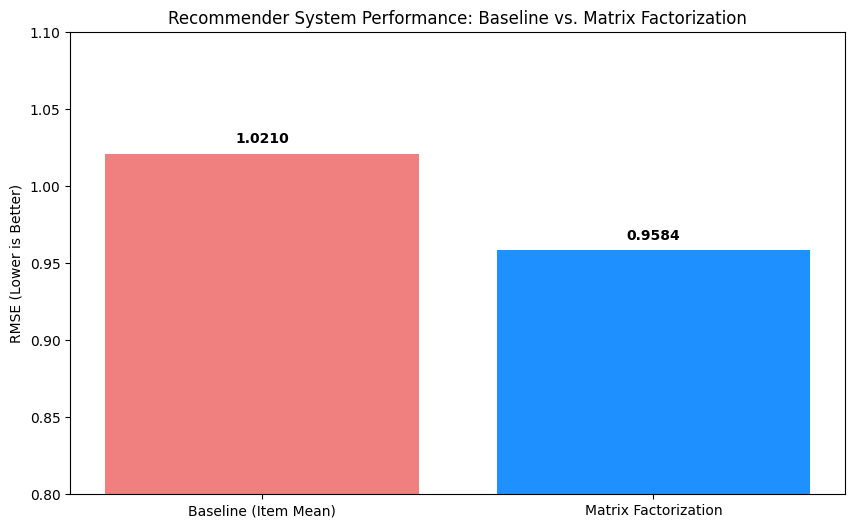

In [21]:
import matplotlib.pyplot as plt

# The final metrics from our evaluation
models = ["Baseline (Item Mean)", "Matrix Factorization"]
rmse_scores = [baseline_rmse, mf_rmse]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, rmse_scores, color=["lightcoral", "dodgerblue"])

plt.ylim(0.8, 1.1)
plt.ylabel("RMSE (Lower is Better)")
plt.title("Recommender System Performance: Baseline vs. Matrix Factorization")

for bar in bars:
  yval = bar.get_height()
  plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.005, f"{yval:.4f}", ha="center", va="bottom", fontweight="bold")

plt.show()

## **Discussion:**
1. **Model Evaluation & Overfitting**
We built a personalized recommender system using the MovieLens 100K dataset.
  - **Baseline (Item Mean):** Guessed the average rating for a movie and achieved an initial RMSE of **1.0210**.
  - **Matrix Factorization:** Built using PyTorch. The core prediction math relies on the dot product of latent user vectors $(p_u)$ and item vectors $(q_u)$, combined with learned biases:
  $$\hat{r}_{ui} = q_i^T p_u + b_u + b_i + \mu$$
  Initially, this model severely overfit the training data. We applied 3 specific architectural constraints to force the AI to learn generalized patterns:
    - Reduced the brain size to exactly $k=8$ latent features
    - Added L2 regularization (weight decay = $1\times10^{-3}$) to prevent extreme multipliers
    - Clamped the final output predictions strictly between 1.0 and 5.0 stars
  These constraints brought out final Matrix Factorization RMSE down to **0.9584**, successfully beating the baseline.

2. **The Sparsity Problem**
A fundamental challenge in collaborative filtering is data sparsity, calculated as
$$Sparsity = 1 - \frac{\text{Actual Ratings}}{\text{Total Users} \times \text{Total Items}}$$
Our User-Item matrix was **93.70% empty**. Traditional baseline methods struggle heavily with this lack of overlapping data. Matrix Factorization elegantly solves this problem by mathematically compressing the massive sparse matrix into smaller dense matrices. By discovering hidden latent features, the model accurately predicts missing ratings using the dot product equation above, even when two users have very few overlapping movie ratings.